In [1]:
!pip install -Uqq fastai && pip install -Uqq torchsummary

**Import Section:**

In [3]:
import warnings

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import torch
from torchsummary import summary
import fastai
from torchvision.models import vgg19 #The CNN we'll be using
from pathlib import Path
from fastai.vision.all import *

from sklearn.model_selection import train_test_split

import gc

# Note About Datasets
These three datasets are evaluated differently due to how the sets were comprised.

### Custard Apple Dataset
This dataset doesn't provide a healthy class for custard apples, just different diseases custard apples can get. It has the most data entries with 8,226 images (some being very similar to each other, or the same image taken a second later, etc.)

### Fig Leaves Dataset
This dataset isn't terribly specific with the diseases the leaves may have, classifying them only as "healthy" or "infected". It has the least amount of entries, 2,321 images.

### Potato Leaf Dataset
This dataset is the most comprehensive with its classes, having a baseline for healthy leaves while also having disease classes. It has around 3,076 images as data entries.



---


Let's get the paths for the images.

In [5]:
custard_apple_path = Path('data/Custard Apple dataset')

fig_leaves_path = Path('data/fig leaves dataset')

potato_leaf_path = Path('data/Potato Leaf Disease Dataset in Uncontrolled Environment')

In [6]:
custard_apple_db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=0),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=Normalize.from_stats(*imagenet_stats)
)

CA_dls = custard_apple_db.dataloaders(custard_apple_path, bs=16)

In [7]:
CA_dls.train_ds

(#6581) [(PILImage mode=RGB size=768x1024, TensorCategory(5)), (PILImage mode=RGB size=768x1024, TensorCategory(5)), (PILImage mode=RGB size=768x576, TensorCategory(2)), (PILImage mode=RGB size=768x1024, TensorCategory(5)), (PILImage mode=RGB size=768x1024, TensorCategory(1)), (PILImage mode=RGB size=768x576, TensorCategory(2)), (PILImage mode=RGB size=768x1024, TensorCategory(4)), (PILImage mode=RGB size=768x576, TensorCategory(2)), (PILImage mode=RGB size=768x1024, TensorCategory(0)), (PILImage mode=RGB size=768x1024, TensorCategory(3)), (PILImage mode=RGB size=768x576, TensorCategory(5)), (PILImage mode=RGB size=768x576, TensorCategory(1)), (PILImage mode=RGB size=768x1024, TensorCategory(5)), (PILImage mode=RGB size=768x576, TensorCategory(2)), (PILImage mode=RGB size=768x1024, TensorCategory(5)), (PILImage mode=RGB size=768x1024, TensorCategory(5)), (PILImage mode=RGB size=768x1024, TensorCategory(1)), (PILImage mode=RGB size=768x1024, TensorCategory(3)), (PILImage mode=RGB size=7

In [8]:
fig_leaf_db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=0),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=Normalize.from_stats(*imagenet_stats)
)

FL_dls = fig_leaf_db.dataloaders(fig_leaves_path, bs=16)

potato_leaf_db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=0),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=Normalize.from_stats(*imagenet_stats)
)

PL_dls = potato_leaf_db.dataloaders(potato_leaf_path, bs=16)

In [9]:
FL_dls.train_ds

(#1857) [(PILImage mode=RGB size=1365x768, TensorCategory(0)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB size=1365x768, TensorCategory(0)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB size=1365x768, TensorCategory(0)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB size=1365x768, TensorCategory(0)), (PILImage mode=RGB size=1365x768, TensorCategory(0)), (PILImage mode=RGB size=1365x768, TensorCategory(0)), (PILImage mode=RGB size=1365x768, TensorCategory(0)), (PILImage mode=RGB size=1365x768, TensorCategory(1)), (PILImage mode=RGB 

In [10]:
PL_dls.train_ds

(#2461) [(PILImage mode=RGB size=1500x1500, TensorCategory(1)), (PILImage mode=RGB size=1500x1500, TensorCategory(6)), (PILImage mode=RGB size=1500x1500, TensorCategory(1)), (PILImage mode=RGB size=1500x1500, TensorCategory(4)), (PILImage mode=RGB size=1500x1500, TensorCategory(1)), (PILImage mode=RGB size=1500x1500, TensorCategory(6)), (PILImage mode=RGB size=1500x1500, TensorCategory(0)), (PILImage mode=RGB size=1500x1500, TensorCategory(1)), (PILImage mode=RGB size=1500x1500, TensorCategory(2)), (PILImage mode=RGB size=1500x1500, TensorCategory(0)), (PILImage mode=RGB size=1500x1500, TensorCategory(0)), (PILImage mode=RGB size=1500x1500, TensorCategory(4)), (PILImage mode=RGB size=1500x1500, TensorCategory(0)), (PILImage mode=RGB size=1500x1500, TensorCategory(1)), (PILImage mode=RGB size=1500x1500, TensorCategory(2)), (PILImage mode=RGB size=1500x1500, TensorCategory(4)), (PILImage mode=RGB size=1500x1500, TensorCategory(0)), (PILImage mode=RGB size=1500x1500, TensorCategory(1)), (

In [11]:
CA_dls.show_batch(max_n=6)

In [12]:
CA_learn = vision_learner(
    CA_dls, 
    vgg19,
    metrics=accuracy
)

FL_learn = vision_learner(
    FL_dls,
    vgg19,
    metrics=accuracy
)

PL_learn = vision_learner(
    PL_dls,
    vgg19,
    metrics=accuracy
)

/Users/poo.ping/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/poo.ping/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
CA_learn.summary()

<div></div>

Sequential (Input shape: 16 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     16 x 64 x 224 x 224 
Conv2d                                    1792       False     
ReLU                                                           
Conv2d                                    36928      False     
ReLU                                                           
____________________________________________________________________________
                     16 x 64 x 112 x 112 
MaxPool2d                                                      
____________________________________________________________________________
                     16 x 128 x 112 x 11 
Conv2d                                    73856      False     
ReLU                                                           
Conv2d                                    147584     False     
ReLU                                                           
___________________________________

In [14]:
CA_learn.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,time
0,0.563914,0.204121,0.932523,04:44


epoch,train_loss,valid_loss,accuracy,time
0,0.208796,0.049027,0.987842,17:33
1,0.101948,0.016398,0.995137,15:19
2,0.075134,0.006501,0.996960,15:44
3,0.029664,0.008451,0.996353,23:12
4,0.020247,0.006864,0.996960,16:49


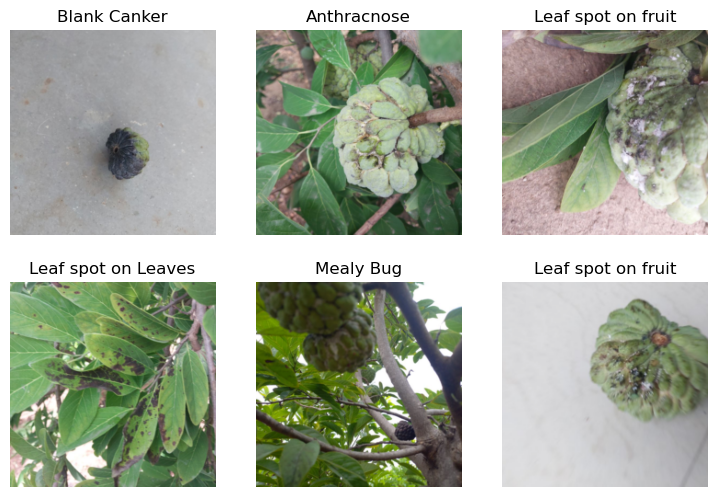

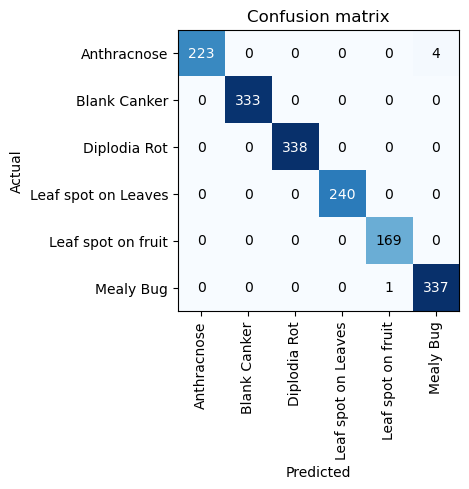

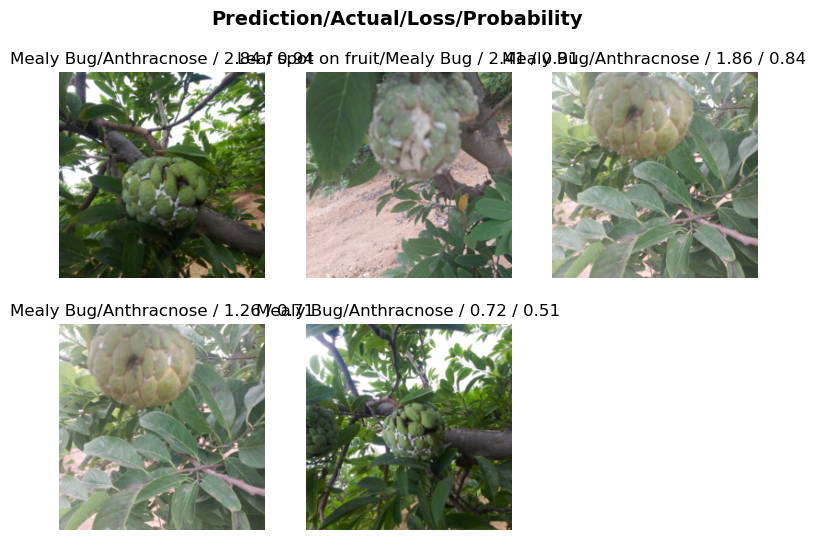

In [15]:
clsInt = ClassificationInterpretation.from_learner(CA_learn)
clsInt.plot_confusion_matrix()
clsInt.plot_top_losses(5)
plt.show()

In [16]:
FL_learn.summary()

<div></div>

Sequential (Input shape: 16 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     16 x 64 x 224 x 224 
Conv2d                                    1792       False     
ReLU                                                           
Conv2d                                    36928      False     
ReLU                                                           
____________________________________________________________________________
                     16 x 64 x 112 x 112 
MaxPool2d                                                      
____________________________________________________________________________
                     16 x 128 x 112 x 11 
Conv2d                                    73856      False     
ReLU                                                           
Conv2d                                    147584     False     
ReLU                                                           
___________________________________

In [17]:
FL_learn.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,time
0,0.722531,0.413581,0.812500,01:58


epoch,train_loss,valid_loss,accuracy,time
0,0.456088,0.301912,0.870690,04:29
1,0.355345,0.253106,0.896552,04:16
2,0.265944,0.209349,0.911638,04:20
3,0.201893,0.214838,0.909483,04:20
4,0.162076,0.188221,0.915948,03:54


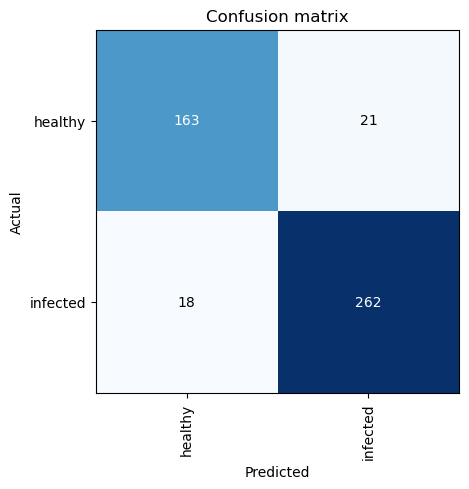

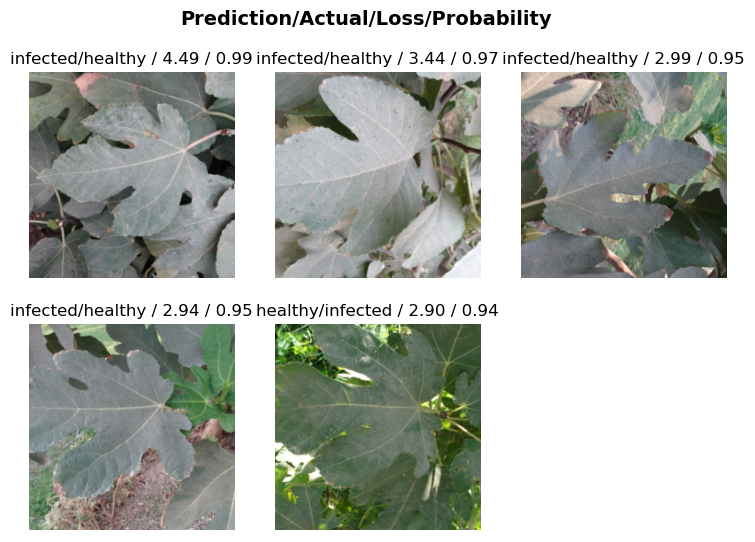

In [18]:
clsInt = ClassificationInterpretation.from_learner(FL_learn)
clsInt.plot_confusion_matrix()
clsInt.plot_top_losses(5)
plt.show()

In [19]:
PL_learn.summary()

<div></div>

Sequential (Input shape: 16 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     16 x 64 x 224 x 224 
Conv2d                                    1792       False     
ReLU                                                           
Conv2d                                    36928      False     
ReLU                                                           
____________________________________________________________________________
                     16 x 64 x 112 x 112 
MaxPool2d                                                      
____________________________________________________________________________
                     16 x 128 x 112 x 11 
Conv2d                                    73856      False     
ReLU                                                           
Conv2d                                    147584     False     
ReLU                                                           
___________________________________

In [20]:
PL_learn.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,time
0,1.847539,1.167148,0.622764,03:24


epoch,train_loss,valid_loss,accuracy,time
0,1.199557,0.899642,0.725203,11:34
1,0.937310,0.842608,0.712195,11:47
2,0.687364,0.754622,0.777236,12:26
3,0.392616,0.713744,0.765854,11:53
4,0.301506,0.703742,0.765854,12:07


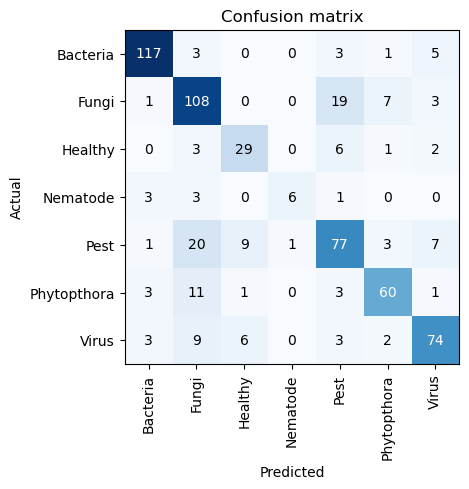

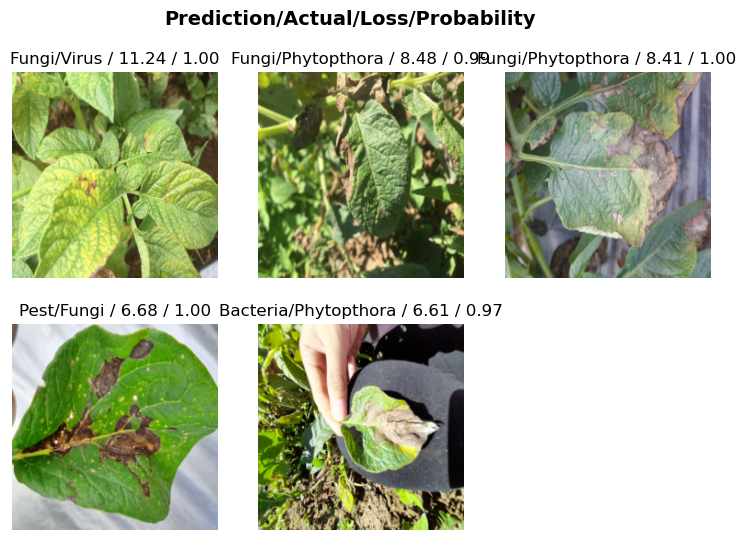

In [21]:
clsInt = ClassificationInterpretation.from_learner(PL_learn)
clsInt.plot_confusion_matrix()
clsInt.plot_top_losses(5)
plt.show()

We can extract the features and targets from each dataset in order to compare the machine learning models on them.

In [23]:
for name, learn, dls in [
                        ("Custard Apple", CA_learn, CA_dls),
                        ("Fig Leaf", FL_learn, FL_dls),
                        ("Potato Leaf", PL_learn, PL_dls)
                    ]:
    model = learn.model.eval()
    device = next(model.parameters()).device
    del learn
    
    with torch.no_grad():
        
        X_list, y_list = [], []
        
        for xb, yb in dls.valid: 
            xb = xb.to(device)

            feats = model[0](xb).detach()
            feats = feats.mean(dim=[2, 3])
            
            X_list.append(feats.cpu().numpy())
            y_list.append(yb.cpu().numpy())
    
    X = np.concatenate(X_list)
    y = np.concatenate(y_list)

    np.savez_compressed(f"{name}_data.npz", X=X, y=y)

    del X, y
    del X_list, y_list
    del model
    del dls
    
    gc.collect()
    torch.mps.empty_cache()

    